## Bergman Minimal Model - BG Forecasting

In [ ]:
!pip install -r ../requirements.txt

Using subject ids: [540 544 552]

Processing subject id: 540
  Initial Gb (mean first 30min): 68.33, initial Ib (basal mean): 0.465
  Initial params: [2.00000000e-02 3.00000000e-02 1.00000000e-03 6.83333333e+01
 4.65461528e-01]
  Bounds lower: [1e-06, 1e-06, 0.0, 30.0, 0.0]
  Bounds upper: [1.0, 1.0, 1.0, 400.0, np.float64(31.0)]
  Fitting Bergman minimal model parameters using least squares...
  Fitted params: p1=0.147795, p2=0.017274, p3=0.07664863, Gb=100.01, Ib=0.052311
  Fit-window metrics: MSE=5096.962, MAE=52.488


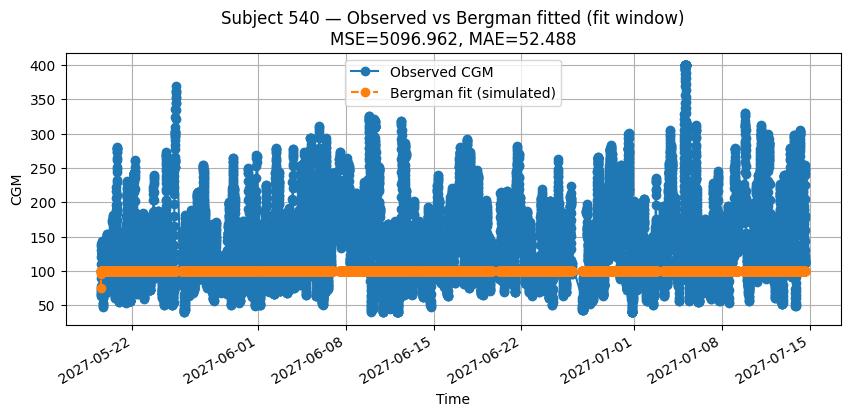

  Forecast anchor index (global): 14841, time: 2027-07-14 15:30:00, G0=242.00


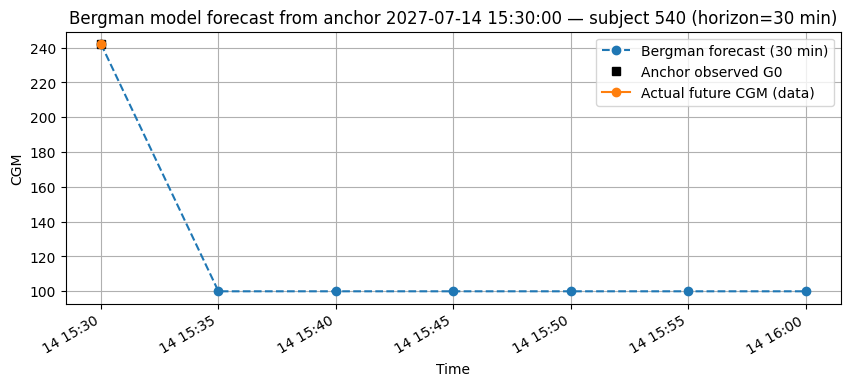

  Done for subject 540. Summary: p1=0.147795, p2=0.017274, p3=0.07664863, Gb=100.01, Ib=0.052311

Processing subject id: 544
  Initial Gb (mean first 30min): 130.33, initial Ib (basal mean): 1.456
  Initial params: [2.00000000e-02 3.00000000e-02 1.00000000e-03 1.30333333e+02
 1.45634230e+00]
  Bounds lower: [1e-06, 1e-06, 0.0, 30.0, 0.0]
  Bounds upper: [1.0, 1.0, 1.0, 400.0, np.float64(56.666666666666664)]
  Fitting Bergman minimal model parameters using least squares...
  Fitted params: p1=0.021356, p2=0.029914, p3=0.01162926, Gb=159.84, Ib=1.456368
  Fit-window metrics: MSE=3475.879, MAE=46.617


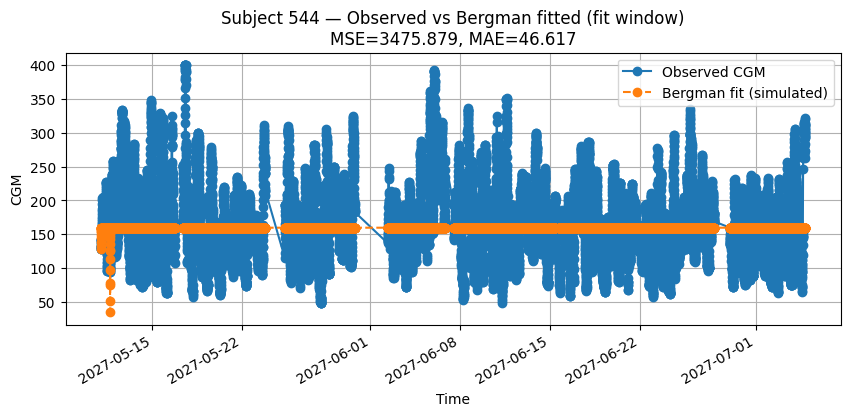

  Forecast anchor index (global): 13338, time: 2027-07-04 21:20:00, G0=262.00


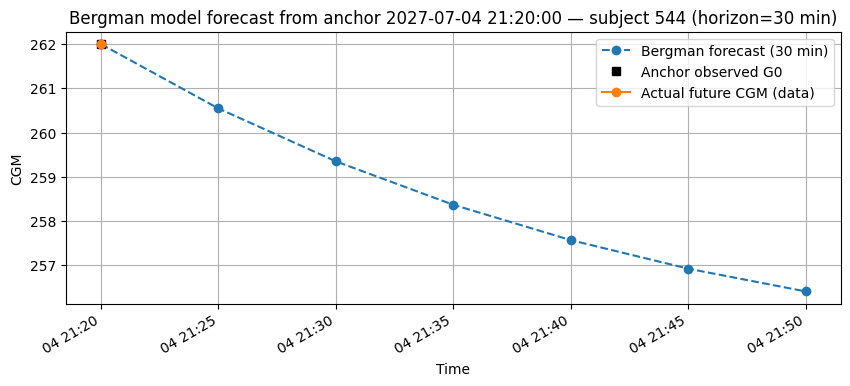

  Done for subject 544. Summary: p1=0.021356, p2=0.029914, p3=0.01162926, Gb=159.84, Ib=1.456368

Processing subject id: 552
  Initial Gb (mean first 30min): 84.50, initial Ib (basal mean): 1.217
  Initial params: [2.00000000e-02 3.00000000e-02 1.00000000e-03 8.45000000e+01
 1.21693901e+00]
  Bounds lower: [1e-06, 1e-06, 0.0, 30.0, 0.0]
  Bounds upper: [1.0, 1.0, 1.0, 400.0, np.float64(45.0)]
  Fitting Bergman minimal model parameters using least squares...
  Simulation failed for params: [1.50401228e-02 1.89521287e-02 1.90302103e-01 1.35535244e+02
 3.25381521e+00] err: ODE solver failed.
  Fitted params: p1=0.029005, p2=0.064143, p3=0.01997527, Gb=144.19, Ib=1.395728
  Fit-window metrics: MSE=2931.761, MAE=42.788


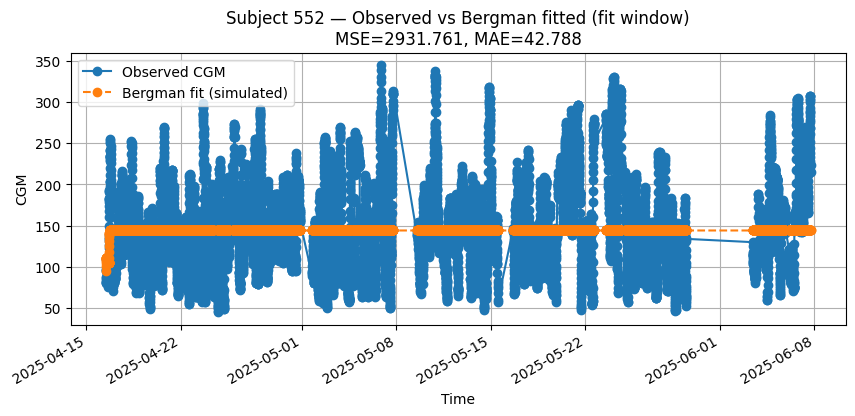

  Forecast anchor index (global): 11443, time: 2025-06-07 17:10:00, G0=215.00


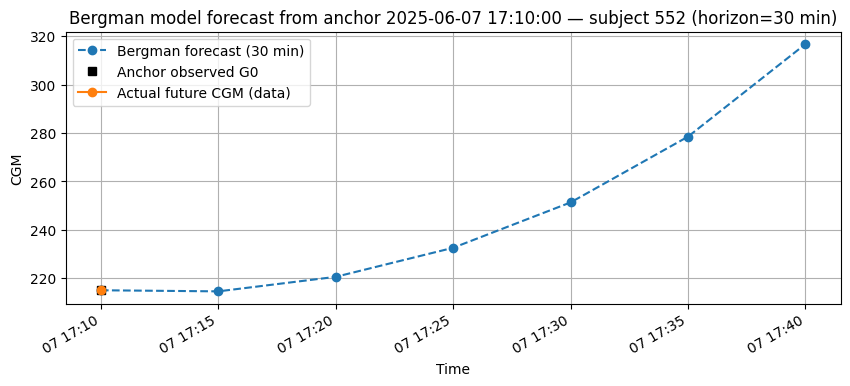

  Done for subject 552. Summary: p1=0.029005, p2=0.064143, p3=0.01997527, Gb=144.19, Ib=1.395728


In [1]:
# Bergman minimal model parameter estimation + forecasting (three subjects)
# Paste into a Jupyter notebook cell and run.
# Requires: numpy, pandas, matplotlib, scipy, scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------ Configuration ------------------
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_ID = None      # None -> first three subjects in file; otherwise set a single id or list of ids
LOOKBACK_MIN = None
FIT_START_IDX = 0
MAX_FIT_MIN = None
FORECAST_MIN = 30      # ensure 30-minute prediction horizon
STEP_MIN = 5
PLOT_EXAMPLE_IDX = None
# ---------------------------------------------------

# ------------------ Load data ----------------------
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# choose subjects: first three if SUBJECT_ID is None
if SUBJECT_ID is None:
    SUBJECT_IDS = df['id'].unique()[:3]
else:
    # allow user to pass single id or list
    if isinstance(SUBJECT_ID, (list, tuple, np.ndarray)):
        SUBJECT_IDS = list(SUBJECT_ID)
    else:
        SUBJECT_IDS = [SUBJECT_ID]

print("Using subject ids:", SUBJECT_IDS)

# ------------------ Bergman model ODEs (shared) ------------------
def bergman_rhs(t, y, p1, p2, p3, Gb, Ib, t_vec, I_vec):
    # y = [G, X]
    I_t = np.interp(t, t_vec, I_vec)
    G, X = y
    dGdt = - (p1 + X) * (G - Gb)
    dXdt = - p2 * X + p3 * (I_t - Ib)
    return [dGdt, dXdt]

def simulate_bergman(params, t_eval, I_t, G0=None, X0=0.0, t_vec=None):
    p1, p2, p3, Gb, Ib = params
    if t_vec is None:
        t_vec = t_eval
    if G0 is None:
        # fallback (note: original placeholder uses insulin interpolation; kept as-is)
        G0 = np.interp(t_eval[0], t_vec, I_t)
    y0 = [G0, X0]
    sol = solve_ivp(bergman_rhs, (t_eval[0], t_eval[-1]), y0,
                    args=(p1, p2, p3, Gb, Ib, t_vec, I_t),
                    t_eval=t_eval, method='RK45', rtol=1e-5, atol=1e-6)
    if not sol.success:
        raise RuntimeError("ODE solver failed.")
    G_sim = sol.y[0]
    X_sim = sol.y[1]
    return G_sim, X_sim

# ------------------ Per-subject processing function ------------------
def process_subject(subject_id):
    print("\n" + "="*70)
    print(f"Processing subject id: {subject_id}")
    sub = df[df['id'] == subject_id].sort_values('date').reset_index(drop=True)

    # Drop rows missing CGM
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if sub.empty:
        print("  No CGM data for subject, skipping.")
        return

    # Insulin proxy (basal + spread bolus)
    spread_bolus_minutes = 30
    spread_steps = max(1, spread_bolus_minutes // STEP_MIN)

    basal = sub['basal'].fillna(0.0).values.astype(float)
    bolus = sub['bolus'].fillna(0.0).values.astype(float)
    bolus_spread = np.convolve(bolus, np.ones(spread_steps)/spread_steps, mode='full')[:len(bolus)]
    I_proxy = basal + bolus_spread

    times = (sub['date'] - sub['date'].iloc[0]).dt.total_seconds().values / 60.0  # minutes since start
    G_obs = sub['CGM'].values.astype(float)

    # Optionally restrict fit window length
    if MAX_FIT_MIN is not None:
        max_samples = int(np.floor(MAX_FIT_MIN / STEP_MIN))
        end_idx = min(len(times), FIT_START_IDX + max_samples)
    else:
        end_idx = len(times)

    t_fit = times[FIT_START_IDX:end_idx]
    G_fit = G_obs[FIT_START_IDX:end_idx]
    I_fit = I_proxy[FIT_START_IDX:end_idx]

    if len(t_fit) < 10:
        print("  Not enough data points in fit window. Skipping subject.")
        return

    # baseline estimates
    Gb_init = np.mean(G_fit[:max(1, int(30/STEP_MIN))])
    Ib_init = np.mean(basal)
    print(f"  Initial Gb (mean first 30min): {Gb_init:.2f}, initial Ib (basal mean): {Ib_init:.3f}")

    # residuals for least squares (closure to use local G_fit/I_fit/t_fit)
    def residuals_to_fit(params):
        p1, p2, p3, Gb, Ib = params
        G0 = float(G_fit[0])
        try:
            G_sim, X_sim = simulate_bergman(params, t_fit, I_fit, G0=G0, X0=0.0, t_vec=t_fit)
        except Exception as e:
            print("  Simulation failed for params:", params, "err:", e)
            return 1e6 * np.ones_like(G_fit)
        res = G_sim - G_fit
        return res

    # initial guesses & bounds
    p1_init = 0.02
    p2_init = 0.03
    p3_init = 1e-3

    x0 = np.array([p1_init, p2_init, p3_init, Gb_init, Ib_init])
    lower = [1e-6, 1e-6, 0.0, 30.0, 0.0]
    upper = [1.0, 1.0, 1.0, 400.0, np.max(I_fit)*10 + 1.0]

    print("  Initial params:", x0)
    print("  Bounds lower:", lower)
    print("  Bounds upper:", upper)

    # fit
    print("  Fitting Bergman minimal model parameters using least squares...")
    res_lsq = least_squares(residuals_to_fit, x0, bounds=(lower, upper),
                            verbose=0, xtol=1e-6, ftol=1e-6, max_nfev=200)
    p_fit = res_lsq.x
    p1_fit, p2_fit, p3_fit, Gb_fit, Ib_fit = p_fit
    print(f"  Fitted params: p1={p1_fit:.6f}, p2={p2_fit:.6f}, p3={p3_fit:.8f}, Gb={Gb_fit:.2f}, Ib={Ib_fit:.6f}")

    # simulate on fit window and metrics
    G_sim_fit, X_sim_fit = simulate_bergman(p_fit, t_fit, I_fit, G0=float(G_fit[0]), X0=0.0, t_vec=t_fit)
    mse_fit = mean_squared_error(G_fit, G_sim_fit)
    mae_fit = mean_absolute_error(G_fit, G_sim_fit)
    print(f"  Fit-window metrics: MSE={mse_fit:.3f}, MAE={mae_fit:.3f}")

    # Plot observed vs fitted (fit window)
    plt.figure(figsize=(10,4))
    plt.plot(sub['date'].iloc[FIT_START_IDX:FIT_START_IDX + len(t_fit)], G_fit, 'o-', label='Observed CGM')
    plt.plot(sub['date'].iloc[FIT_START_IDX:FIT_START_IDX + len(t_fit)], G_sim_fit, 'o--', label='Bergman fit (simulated)')
    plt.xlabel("Time"); plt.ylabel("CGM")
    plt.title(f"Subject {subject_id} — Observed vs Bergman fitted (fit window)\nMSE={mse_fit:.3f}, MAE={mae_fit:.3f}")
    plt.legend(); plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()

    # ------------------ Forecasting from anchor / initial point ------------------
    anchor_global_idx = FIT_START_IDX + len(t_fit) - 1
    anchor_time = sub['date'].iloc[anchor_global_idx]
    G0_anchor = sub['CGM'].iloc[anchor_global_idx]
    print(f"  Forecast anchor index (global): {anchor_global_idx}, time: {anchor_time}, G0={G0_anchor:.2f}")

    n_forecast_steps = int(np.ceil(FORECAST_MIN / STEP_MIN))
    t_forecast_rel = np.arange(0, (n_forecast_steps + 1) * STEP_MIN, STEP_MIN)
    t_anchor_abs = (anchor_time - sub['date'].iloc[0]).total_seconds() / 60.0
    t_forecast_abs = t_anchor_abs + t_forecast_rel

    # Build future insulin series (use available future insulin if present else assume last basal)
    start_idx = anchor_global_idx
    end_idx = min(len(sub) - 1, anchor_global_idx + n_forecast_steps)
    I_future_available = False
    if end_idx > start_idx:
        I_future = I_proxy[start_idx: end_idx + 1]
        if len(I_future) < len(t_forecast_rel):
            last_basal = basal[-1] if len(basal)>0 else 0.0
            extend_len = len(t_forecast_rel) - len(I_future)
            I_future = np.concatenate([I_future, np.repeat(last_basal, extend_len)])
        I_future_available = True
    else:
        last_basal = basal[-1] if len(basal)>0 else 0.0
        I_future = np.repeat(last_basal, len(t_forecast_rel))

    t_vec_for_sim = t_forecast_abs
    t_eval_sim = t_forecast_abs
    X0_anchor = float(X_sim_fit[-1]) if 'X_sim_fit' in locals() else 0.0

    G_forecast_sim, X_forecast_sim = simulate_bergman(p_fit, t_eval_sim, I_future, G0=G0_anchor, X0=X0_anchor, t_vec=t_vec_for_sim)

    # convert to datetimes for plotting
    t_datetimes = [sub['date'].iloc[0] + pd.Timedelta(minutes=float(tt)) for tt in t_eval_sim]

    # actual CGM in future (if available)
    actual_mask = (sub['date'] >= anchor_time) & (sub['date'] <= anchor_time + pd.Timedelta(minutes=FORECAST_MIN))
    actual_future_times = sub.loc[actual_mask, 'date']
    actual_future_cgm = sub.loc[actual_mask, 'CGM'].values

    # Plot forecast (30-minute horizon)
    plt.figure(figsize=(10,4))
    plt.plot(t_datetimes, G_forecast_sim, 'o--', label=f'Bergman forecast ({FORECAST_MIN} min)')
    plt.plot(anchor_time, G0_anchor, 'ks', label='Anchor observed G0')
    if len(actual_future_cgm) > 0:
        plt.plot(actual_future_times, actual_future_cgm, 'o-', label='Actual future CGM (data)')
    plt.xlabel("Time"); plt.ylabel("CGM")
    plt.title(f"Bergman model forecast from anchor {anchor_time} — subject {subject_id} (horizon={FORECAST_MIN} min)")
    plt.legend(); plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()

    print(f"  Done for subject {subject_id}. Summary: p1={p1_fit:.6f}, p2={p2_fit:.6f}, p3={p3_fit:.8f}, Gb={Gb_fit:.2f}, Ib={Ib_fit:.6f}")
    print("="*70)

# ------------------ Run for each selected subject ------------------
for sid in SUBJECT_IDS:
    try:
        process_subject(sid)
    except Exception as e:
        print(f"Error processing subject {sid}: {e}")


C:\Users\msbdj\AppData\Local\Temp\ipykernel_7668\3212909882.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM'] = df['CGM'].fillna(method='ffill').fillna(method='bfill').astype(float)


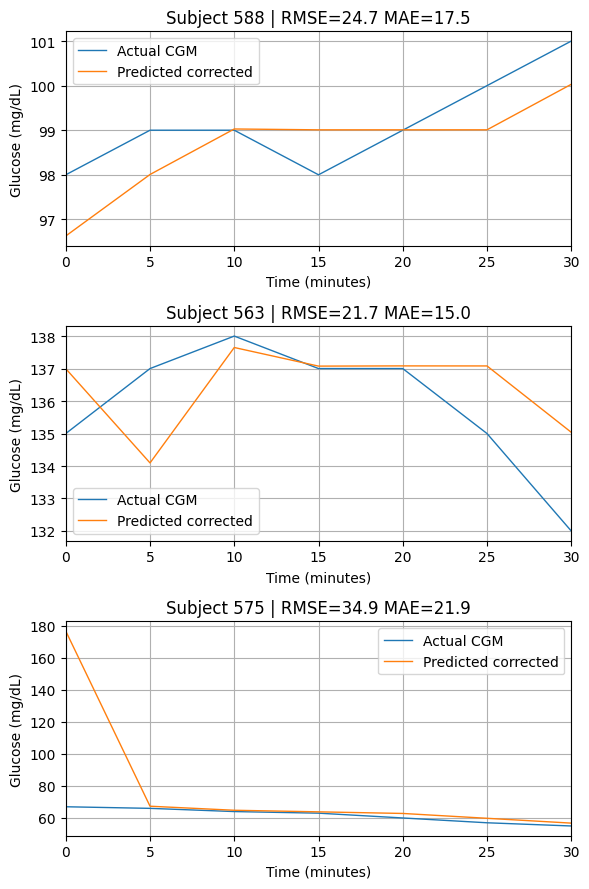

 id  RMSE_mg/dL  MAE_mg/dL  MAPE_pct         notes
588   24.689999  17.472782 11.491026 n_preds=15835
563   21.675799  15.048451 10.615636 n_preds=15719
575   34.860341  21.891293 16.440735 n_preds=15577


In [12]:
# Single cell: Improved hybrid mechanistic + residual-correction model for lower RMSE
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize
from math import sqrt

# ---------------- user-changeable params ----------------
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECTS_TO_PLOT = 3
TRAIN_DAYS = 1
DT_MIN = 5
HORIZON_MIN = 30
DT_H = DT_MIN/60.0
SAMPLES_PER_DAY = int(24*60/DT_MIN)
TRAIN_SAMPLES = TRAIN_DAYS * SAMPLES_PER_DAY
N_RESTARTS = 8         # multi-starts for optimizer
SMOOTH_MED = 3         # median smoothing window for CGM
# -------------------------------------------------------

horizon_steps = int(HORIZON_MIN / DT_MIN)
np.random.seed(42)

# simulator: glucose G, insulin action X, carb gut Y
def simulate(params, G0, X0, Y0, carbs, insulin_step, steps=None):
    p1, tau_i, insulin_scale, Gb, tau_c, carb_sens = params
    n = len(carbs) if steps is None else steps
    G = np.empty(n); X = np.empty(n); Y = np.empty(n)
    g, x, y = float(G0), float(X0), float(Y0)
    for t in range(n):
        c = carbs[t]
        ins = insulin_step[t]
        dy = (-y / tau_c + c) * DT_H
        y = y + dy
        Ra = (y / tau_c) * carb_sens
        dx = (- x / tau_i + insulin_scale * ins) * DT_H
        x = x + dx
        dg = ( - (p1 + x) * (g - Gb) + Ra ) * DT_H
        g = g + dg
        G[t] = g; X[t] = x; Y[t] = y
    return G, X, Y

def fit_obj(theta, G0, X0, Y0, carbs, insulin_step, observed):
    pred, _, _ = simulate(theta, G0, X0, Y0, carbs, insulin_step)
    return np.mean((pred - observed)**2)

# load & minimal preprocessing
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
cols = ["date","CGM","carbs","bolus","basal","id"]
df = df[cols].copy()
df['carbs'] = df['carbs'].fillna(0).astype(float)
df['bolus'] = df['bolus'].fillna(0).astype(float)
df['basal'] = df['basal'].fillna(0).astype(float)
df['CGM'] = df['CGM'].fillna(method='ffill').fillna(method='bfill').astype(float)
df['CGM'] = df['CGM'].clip(30, 400)

ids_all = df['id'].dropna().unique()
ids = ids_all[:SUBJECTS_TO_PLOT] if len(ids_all) >= SUBJECTS_TO_PLOT else ids_all

metrics = []
fig, axes = plt.subplots(len(ids), 1, figsize=(6, 3*len(ids)))
if len(ids)==1: axes=[axes]

for ax, sid in zip(axes, ids):
    sub = df[df['id']==sid].reset_index(drop=True)
    if len(sub) < TRAIN_SAMPLES + horizon_steps + 10:
        metrics.append((sid, np.nan, np.nan, np.nan, "insufficient data"))
        ax.text(0.5,0.5,f"not enough data for id {sid}", ha='center'); continue

    # split train/test
    train = sub.iloc[:TRAIN_SAMPLES].reset_index(drop=True)
    test = sub.iloc[TRAIN_SAMPLES:].reset_index(drop=True)
    if len(test) < horizon_steps+1:
        metrics.append((sid, np.nan, np.nan, np.nan, "not enough test"))
        ax.text(0.5,0.5,f"not enough test for id {sid}", ha='center'); continue

    # smooth CGM (median) to reduce noise used for fitting
    train_cgm = pd.Series(train['CGM']).rolling(SMOOTH_MED, center=True, min_periods=1).median().values
    test_cgm  = pd.Series(test['CGM']).rolling(SMOOTH_MED, center=True, min_periods=1).median().values

    # inputs per step
    train_ins = train['bolus'].values + train['basal'].values * DT_H
    test_ins  = test['bolus'].values + test['basal'].values * DT_H
    train_carbs = train['carbs'].values
    test_carbs  = test['carbs'].values

    # combined arrays for simulation & rolling
    combined_carbs = np.concatenate([train_carbs, test_carbs])
    combined_ins = np.concatenate([train_ins, test_ins])
    combined_cgm = np.concatenate([train_cgm, test_cgm])
    combined_raw_cgm = np.concatenate([train['CGM'].values, test['CGM'].values])  # for true metrics

    # initial states
    G0 = train_cgm[0]; X0 = 0.0; Y0 = 0.0

    # multi-start parameter estimation (randomized starts near reasonable physiology)
    best_val = np.inf; best_theta = None
    # base guess
    base = np.array([0.02, 1.5, 0.8, float(np.median(train_cgm)), 1.0, 3.0])
    bounds = [(1e-4,0.5),(0.1,6.0),(1e-3,5.0),(60,200),(0.1,6.0),(0.1,30.0)]
    for r in range(N_RESTARTS):
        if r==0:
            theta0 = base.copy()
        else:
            # small random perturbation
            theta0 = base * (1 + 0.5*(np.random.rand(len(base))-0.5))
            theta0[3] = base[3] + np.random.randn()*10  # Gb variation
        try:
            res = minimize(lambda th: fit_obj(th, G0, X0, Y0, train_carbs, train_ins, train_cgm),
                           theta0, bounds=bounds, method='L-BFGS-B', options={'maxiter':800})
            if res.fun < best_val:
                best_val = res.fun; best_theta = res.x
        except Exception:
            continue
    if best_theta is None:
        theta_hat = base.copy()
    else:
        theta_hat = best_theta

    # simulate across combined timeline to get warm states
    G_sim, X_sim, Y_sim = simulate(theta_hat, G0, X0, Y0, combined_carbs, combined_ins)

    # Build residual corrector (linear) on training residuals:
    # features: [1, pred_t, recent_cgm_t, slope_t] -> residual = true - pred
    # compute predictions on training from model (one-step-ahead predictions aligned with training times)
    preds_train = G_sim[:len(train)]  # model's simulated values during train
    # recent CGM and slope: use raw training CGM (smoothed) and last delta (5-min slope)
    recent = combined_cgm[:len(train)]
    slope = np.concatenate([[0], np.diff(recent)]) / DT_H  # mg/dL per hour (not strictly needed, but helpful)
    # assemble design matrix (exclude first few points to avoid NaN slope)
    X_design = np.column_stack([np.ones(len(preds_train)), preds_train, recent, slope])
    y_resid = train['CGM'].values - preds_train  # residuals using raw CGM targets
    # linear least squares (regularized tiny ridge to avoid ill-conditioning)
    lam = 1e-4
    A = X_design
    w = np.linalg.solve(A.T @ A + lam*np.eye(A.shape[1]), A.T @ y_resid)

    # Rolling predictions across test; apply linear correction to each predicted horizon outcome
    n_train = len(train)
    n_combined = len(combined_carbs)
    y_preds = []; y_trues = []
    for i in range(n_train-1, n_combined - horizon_steps):
        g_init = G_sim[i]; x_init = X_sim[i]; y_init = Y_sim[i]
        fut_c = combined_carbs[i+1 : i+1+horizon_steps]
        fut_ins = combined_ins[i+1 : i+1+horizon_steps]
        Gf, _, _ = simulate(theta_hat, g_init, x_init, y_init, fut_c, fut_ins, steps=horizon_steps)
        pred_val = Gf[-1]
        # compute correction features at prediction time t = i (use smoothed combined_cgm and slope)
        recent_t = combined_cgm[i]
        slope_t = (combined_cgm[i] - combined_cgm[i-1]) / DT_H if i>0 else 0.0
        feat = np.array([1.0, pred_val, recent_t, slope_t])
        corr = feat @ w
        corrected = pred_val + corr
        true_idx = i + horizon_steps
        true_val = combined_raw_cgm[true_idx]
        if np.isfinite(corrected) and np.isfinite(true_val):
            y_preds.append(corrected); y_trues.append(true_val)

    if len(y_trues)==0:
        metrics.append((sid, np.nan, np.nan, np.nan, "no preds"))
        ax.text(0.5,0.5,f"no preds for id {sid}", ha='center'); continue

    y_preds = np.array(y_preds); y_trues = np.array(y_trues)
    errs = y_preds - y_trues
    rmse = sqrt(np.mean(errs**2)); mae = np.mean(np.abs(errs))
    nonzero = y_trues != 0
    mape = np.mean(np.abs(errs[nonzero] / y_trues[nonzero]))*100 if nonzero.any() else np.nan
    metrics.append((sid, float(rmse), float(mae), float(mape), f"n_preds={len(y_trues)}"))

    # For plot: show one 0..30 min window starting at first test index
    plot_start = n_train
    g_init = G_sim[plot_start-1]; x_init = X_sim[plot_start-1]; y_init = Y_sim[plot_start-1]
    fut_c = combined_carbs[plot_start : plot_start + horizon_steps]
    fut_ins = combined_ins[plot_start : plot_start + horizon_steps]
    Gf, _, _ = simulate(theta_hat, g_init, x_init, y_init, fut_c, fut_ins, steps=horizon_steps)
    # apply correction to full predicted series step-by-step (use dynamic correction using features computed at each step)
    pred_series = [g_init]
    for k in range(horizon_steps):
        pv = Gf[k]
        idx_t = plot_start - 1 + k + 1  # time index at which pv corresponds
        recent_t = combined_cgm[idx_t-1] if idx_t-1 >=0 else combined_cgm[0]
        slope_t = (combined_cgm[idx_t-1] - combined_cgm[idx_t-2]) / DT_H if idx_t-2 >=0 else 0.0
        feat = np.array([1.0, pv, recent_t, slope_t])
        corr = feat @ w
        pred_series.append(pv + corr)
    pred_series = np.array(pred_series)
    # actual series: include current CGM at test start and next horizon_steps raw
    actual_series = combined_raw_cgm[plot_start-1 : plot_start + horizon_steps]
    minutes = np.arange(0, (horizon_steps+1)*DT_MIN, DT_MIN)

    ax.plot(minutes, actual_series, label='Actual CGM', linewidth=1)
    ax.plot(minutes, pred_series, label='Predicted corrected', linewidth=1)
    ax.set_xlim(0, HORIZON_MIN)
    ax.set_xlabel("Time (minutes)")
    ax.set_ylabel("Glucose (mg/dL)")
    ax.set_title(f"Subject {sid} | RMSE={rmse:.1f} MAE={mae:.1f}")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

# print metrics table
metrics_df = pd.DataFrame(metrics, columns=["id","RMSE_mg/dL","MAE_mg/dL","MAPE_pct","notes"])
print(metrics_df.to_string(index=False))
